---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 8. Autoencoders para Compressão de Imagem

Este notebook introduz os autoencoders — redes neurais simétricas usadas para comprimir e reconstruir dados — no contexto do processamento de imagem.

Vamos construir um autoencoder simples em PyTorch, testar diferentes tamanhos de camada latente e comparar reconstruções com as imagens originais.

No final, discutimos o paralelismo com métodos clássicos de compressão como JPEG.

## 8.1. Dataset e visualização

Este notebook introduz os **autoencoders**, um tipo de rede neural voltada para **compressão e reconstrução de dados**.  
Antes de construir o modelo, é importante observar as imagens com que se vai trabalhar.

1. **Carregamento e transformação dos dados:**  
   - O *dataset* **MNIST** contém 60 000 imagens de dígitos manuscritos (0–9), em escala de cinzentos e tamanho 28×28 px.  
   - `transforms.ToTensor()` converte cada imagem PIL num tensor PyTorch normalizado no intervalo \([0, 1]\).  
   - As imagens são organizadas em *batches* de 64 elementos pelo `DataLoader`.

2. **Visualização de amostras:**  
   - `next(iter(dataloader))` obtém o primeiro *batch* de imagens e rótulos.  
   - O ciclo `for` exibe 8 imagens do lote, em tons de cinzento (`cmap="gray"`).  
   - `plt.suptitle()` adiciona um título à figura para contextualizar a visualização.

3. **Objetivo pedagógico:**  
   Esta célula serve para confirmar a integridade dos dados e familiarizar os estudantes com o formato tensorial das imagens.  
   O MNIST é ideal para experimentação porque:
   - é pequeno e rápido de treinar;  
   - tem uma estrutura simples mas suficiente para demonstrar **redução de dimensionalidade**, **reconstrução** e **representação latente**.

Nos próximos blocos, estas imagens serão comprimidas e reconstruídas por um autoencoder, permitindo visualizar como a rede “vê” e sintetiza a informação essencial dos dígitos.

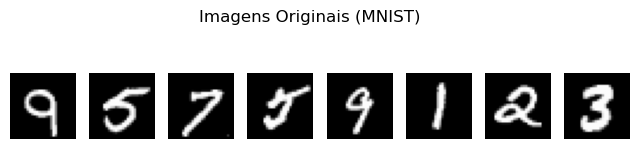

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

images, _ = next(iter(dataloader))
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(images[i][0], cmap="gray")
    plt.axis("off")
plt.suptitle("Imagens Originais (MNIST)")
plt.show()

## 8.2. Definir Autoencoder

Aqui é criado um **autoencoder totalmente ligado (fully connected)** — uma arquitetura clássica usada para compressão e reconstrução de dados, onde a rede aprende a representar as imagens num espaço de menor dimensão.

1. **Estrutura geral:**  
   O modelo divide-se em duas partes simétricas:
   - **Encoder:** comprime a imagem para uma representação compacta (vetor de características).  
   - **Decoder:** reconstrói a imagem original a partir dessa representação comprimida.

2. **Encoder:**  
   - `nn.Flatten()` converte a imagem 28×28 num vetor de 784 valores.  
   - Duas camadas lineares reduzem progressivamente a dimensionalidade:  
     784 → 128 → *bottleneck_dim* (por omissão, 32).  
   - A ativação `ReLU` introduz não linearidade, permitindo que o modelo capture padrões mais complexos.

3. **Decoder:**  
   - Realiza o processo inverso: 32 → 128 → 784 → imagem reconstruída (1×28×28).  
   - A ativação final `Sigmoid()` garante valores no intervalo [0, 1], compatíveis com as intensidades das imagens MNIST.  
   - `nn.Unflatten()` reconfigura o vetor de saída no formato original de imagem.

4. **Parâmetro `bottleneck_dim`:**  
   Controla o grau de compressão — quanto menor o valor, mais informação se perde, mas mais o modelo é forçado a aprender **representações eficientes**.

**Nota pedagógica:**  
Este autoencoder é uma introdução conceitual.  
Mesmo sem convoluções, ele permite observar o princípio de **codificação latente**, onde a rede aprende um “resumo” numérico das imagens.  
Nas próximas células, veremos como esta arquitetura é treinada para minimizar a diferença entre a imagem original e a reconstruída, tipicamente através de uma função de perda de erro quadrático médio (MSE).

In [2]:
class Autoencoder(nn.Module):
    def __init__(self, bottleneck_dim=32):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

## 8.3. Treinar Autoencoder

Nesta célula realiza-se o treino do autoencoder para que aprenda a **reconstruir as imagens MNIST** a partir das suas representações comprimidas.

1. **Configuração do treino:**
   - O modelo é movido para GPU (`cuda`) se disponível, caso contrário usa CPU.  
   - A função de perda (`MSELoss`) mede o erro quadrático médio entre a imagem original e a reconstruída, funcionando como indicador direto de qualidade de reconstrução.  
   - O otimizador `Adam` ajusta os pesos com taxa de aprendizagem de 0.001, equilibrando velocidade e estabilidade.

2. **Ciclo de treino por época:**
   - Cada *batch* de imagens passa pelo modelo (`outputs = model(images)`), produzindo reconstruções.  
   - Calcula-se a perda comparando `outputs` com as imagens originais.  
   - Executam-se os três passos padrão de treino:
     1. `optimizer.zero_grad()` — limpa gradientes antigos;  
     2. `loss.backward()` — propaga o erro;  
     3. `optimizer.step()` — atualiza os pesos.  
   - A perda acumulada (`running_loss`) é usada para calcular a média por época, impressa no final.

3. **Interpretação dos resultados:**
   - Uma **perda decrescente** indica que o autoencoder está a aprender a representar as imagens de forma consistente.  
   - Se a perda estagnar ou aumentar, pode ajustar-se a taxa de aprendizagem, o número de épocas, ou a dimensão do *bottleneck*.

**Nota pedagógica:**  
O treino de um autoencoder não requer rótulos — é **aprendizagem não supervisionada**.  
A rede tenta apenas reproduzir a sua entrada, aprendendo internamente uma representação latente (*encoding*) que pode depois ser usada para:
- redução de dimensionalidade,  
- deteção de anomalias (reconstruções más = padrões raros),  
- ou geração de novos exemplos (variantes como *Variational Autoencoders*).  

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(bottleneck_dim=32).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(epochs):
    running_loss = 0.0
    progress_bar = tqdm(dataloader, desc=f"Época {epoch+1}/{epochs}", leave=True, ncols=80)
    
    for images, _ in progress_bar:
        images = images.to(device)
        outputs = model(images)
        loss = criterion(outputs, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")
    
    print(f"Época {epoch+1} concluída — Loss médio: {running_loss / len(dataloader):.4f}")

Época 1/5: 100%|█████████████████| 938/938 [02:26<00:00,  6.42it/s, loss=0.0200]


Época 1 concluída — Loss médio: 0.0366


Época 2/5: 100%|█████████████████| 938/938 [02:58<00:00,  5.27it/s, loss=0.0147]


Época 2 concluída — Loss médio: 0.0157


Época 3/5: 100%|█████████████████| 938/938 [02:36<00:00,  6.00it/s, loss=0.0098]


Época 3 concluída — Loss médio: 0.0120


Época 4/5: 100%|█████████████████| 938/938 [02:50<00:00,  5.49it/s, loss=0.0103]


Época 4 concluída — Loss médio: 0.0101


Época 5/5: 100%|█████████████████| 938/938 [03:14<00:00,  4.82it/s, loss=0.0099]

Época 5 concluída — Loss médio: 0.0091


## 8.4. Visualizar imagens reconstruídas

Esta célula avalia qualitativamente o desempenho do autoencoder, comparando **as imagens originais e as reconstruídas**.

1. **Modo de avaliação:**  
   - `model.eval()` coloca o modelo em modo de inferência, desativando camadas como *dropout* e *batch normalization*.  
   - O bloco `torch.no_grad()` impede o cálculo de gradientes, tornando a execução mais leve e rápida.

2. **Geração das reconstruções:**  
   - Obtém-se um *batch* de imagens reais do *dataloader*.  
   - As imagens são passadas pelo modelo (`model(images)`), que devolve as reconstruções correspondentes.  
   - Não é usada nenhuma métrica aqui — o objetivo é **visualizar** a qualidade da compressão e reconstrução.

3. **Visualização lado a lado:**  
   - O *subplot* é organizado em **duas linhas de 8 imagens**:  
     - Linha superior → imagens originais.  
     - Linha inferior → versões reconstruídas pelo autoencoder.  
   - As imagens são mostradas em tons de cinzento (`cmap="gray"`) e sem eixos para facilitar a comparação.

4. **Interpretação:**  
   - Se o modelo aprendeu bem, as reconstruções mantêm as formas gerais dos dígitos, mesmo com pequenas perdas de nitidez.  
   - Diferenças marcantes (borrões, confusões entre números) indicam que o *bottleneck* é demasiado pequeno ou que o treino foi insuficiente.

**Nota pedagógica:**  
Esta visualização é essencial para compreender o funcionamento interno de um autoencoder:  
a rede não copia as imagens diretamente, mas aprende uma **representação latente** — um conjunto de valores que codifica as características principais (contorno, orientação, intensidade).  
O sucesso da reconstrução mostra que o modelo conseguiu capturar a estrutura subjacente dos dados, um passo fundamental para tarefas como **compressão, remoção de ruído ou deteção de anomalias**.  

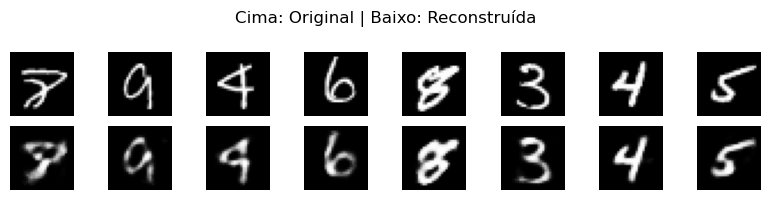

In [4]:
model.eval()
with torch.no_grad():
    images, _ = next(iter(dataloader))
    images = images.to(device)
    reconstructions = model(images)

plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(2, 8, i+1)
    plt.imshow(images[i][0].cpu(), cmap="gray")
    plt.axis("off")
    plt.subplot(2, 8, i+9)
    plt.imshow(reconstructions[i][0].cpu(), cmap="gray")
    plt.axis("off")
plt.suptitle("Cima: Original | Baixo: Reconstruída")
plt.tight_layout()
plt.show()

## 8.5. [AVANÇADO] Convolutional Autoencoder (CAE)

Este modelo é uma versão mais realista do autoencoder anterior.  
Ao invés de achatar as imagens, usa **camadas convolucionais** que preservam a estrutura espacial e capturam padrões locais (bordas, curvas, texturas).

1. **Encoder:**
   - Duas camadas `Conv2d` com `stride=2` reduzem gradualmente a resolução de 28×28 → 14×14 → 7×7.  
   - O número de canais aumenta (1→8→16) para capturar mais características à medida que a imagem é comprimida.  
   - A saída (7×7×16 = 784 valores) constitui o *bottleneck* latente.

2. **Decoder:**
   - Duas camadas `ConvTranspose2d` realizam o processo inverso, reamostrando de 7×7 → 14×14 → 28×28.  
   - A ativação final `Sigmoid()` devolve valores entre 0 e 1, compatíveis com o MNIST.

3. **Vantagem sobre a versão densa:**
   - Mantém a coerência espacial das imagens.  
   - Aprende filtros reutilizáveis que reconhecem formas locais.  
   - É a base dos autoencoders usados em compressão, *denoising* e pré-treino de redes convolucionais profundas.

In [5]:
class ConvAutoencoder(nn.Module):
    def __init__(self, bottleneck_channels=16):
        super(ConvAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),   # 28→14
            nn.ReLU(True),
            nn.Conv2d(8, bottleneck_channels, kernel_size=3, stride=2, padding=1),  # 14→7
            nn.ReLU(True)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(bottleneck_channels, 8, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7→14
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14→28
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

## 8.6. [AVANÇADO] Treino do Convolutional Autoencoder

O treino segue o mesmo princípio da versão anterior:
- **Entrada e saída** são as mesmas imagens (aprendizagem não supervisionada).  
- O modelo aprende a minimizar o erro de reconstrução (`MSELoss`).  
- O `tqdm` mostra o progresso por *batch* e a perda média por época.

Como o modelo preserva a estrutura espacial, as reconstruções são visualmente mais nítidas e fiéis.  
Mesmo com poucas épocas, já se observa uma melhoria clara face à versão totalmente ligada.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(epochs):
    running_loss = 0.0
    pbar = tqdm(dataloader, desc=f"Época {epoch+1}/{epochs}", ncols=80)
    model.train()
    for images, _ in pbar:
        images = images.to(device)
        outputs = model(images)
        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    print(f"Época {epoch+1} — Loss médio: {running_loss / len(dataloader):.4f}")

Época 1/5: 100%|█████████████████| 938/938 [01:23<00:00, 11.22it/s, loss=0.0023]


Época 1 — Loss médio: 0.0232


Época 2/5: 100%|█████████████████| 938/938 [01:22<00:00, 11.32it/s, loss=0.0014]


Época 2 — Loss médio: 0.0017


Época 3/5: 100%|█████████████████| 938/938 [01:19<00:00, 11.86it/s, loss=0.0010]


Época 3 — Loss médio: 0.0012


Época 4/5: 100%|█████████████████| 938/938 [01:10<00:00, 13.31it/s, loss=0.0010]


Época 4 — Loss médio: 0.0010


Época 5/5: 100%|█████████████████| 938/938 [00:31<00:00, 29.42it/s, loss=0.0008]

Época 5 — Loss médio: 0.0009


## 8.7. [AVANÇADO] Avaliação visual do Convolutional Autoencoder

A comparação entre as imagens originais e as reconstruídas revela que:
- Os dígitos mantêm o contorno e a intensidade originais.  
- As bordas estão mais definidas do que na versão densa.  
- O modelo aprendeu filtros convolucionais que identificam traços característicos dos números.

**Conclusão:**  
O *Convolutional Autoencoder* aproxima-se muito mais do comportamento dos autoencoders usados em aplicações reais — conseguindo reconstruções visuais de alta qualidade a partir de uma representação latente compacta.

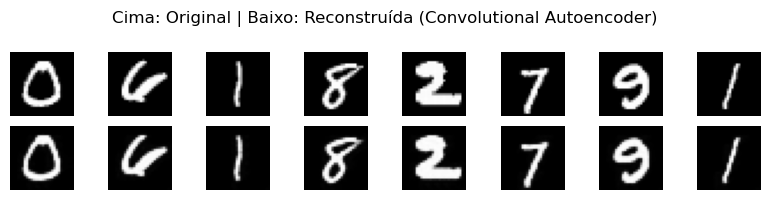

In [7]:
model.eval()
with torch.no_grad():
    images, _ = next(iter(dataloader))
    images = images.to(device)
    recon = model(images)

plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(2, 8, i+1)
    plt.imshow(images[i][0].cpu(), cmap="gray")
    plt.axis("off")
    plt.subplot(2, 8, i+9)
    plt.imshow(recon[i][0].cpu(), cmap="gray")
    plt.axis("off")
plt.suptitle("Cima: Original | Baixo: Reconstruída (Convolutional Autoencoder)")
plt.tight_layout()
plt.show()

## 8.8. Discussão sobre compressão e representação

- O *bottleneck* controla o grau de compressão.
- Representações latentes compactas podem capturar estruturas essenciais da imagem.
- Autoencoders são comparáveis a JPEG na ideia de compactar mantendo o essencial.
- Compressão aprendida pode adaptar-se melhor a certos domínios de dados do que técnicas fixas como DCT.